# PV & Wind Power Curve Modeling

Erick Chauke

Physics-informed and data-driven power curve models for two PV plants and two wind plants, fit
from source power-curve grids (input files, gitignored). Six standalone models: PV1, PV2,
PV-combined, Wind1, Wind2, Wind-combined.

## Setup

Imports and one config cell for the source path and adjustable parameters.

### Imports

Numeric, tabular, plotting, and Excel-reading libraries used throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

### Configuration

File path and adjustable parameters used by every later section.

In [2]:
# Config: file path and adjustable params. Capacity values sourced from each sheet's
# title cell (row 0, col 0), e.g. "Installed Capacity: 75 MW".
DATA_PATH = "data/FPCs.xlsm"

PV_IRRADIANCE_STEP = 50    # W/m^2
PV_TEMP_STEP = 5           # deg C
WIND_VELOCITY_STEP = 0.5   # m/s
WIND_DIRECTION_STEP = 15   # deg

CV_FOLDS = 5

CAPACITY_MW = {
    "PV1": 75.0,
    "PV2": 75.0,
    "Wind1": 102.0,
    "Wind2": 86.6,
}

## Data Loading & Grid Parsing

Each sheet is a 2D power-curve grid, parsed by position (not pandas' auto-detected headers, which the merged/label cells break).

### Grid parsing helper

Positionally slices a sheet into capacity label, x-axis, y-axis, and power grid.

In [3]:
def parse_grid_sheet(path, sheet_name):
    """Positional parse of one FPCs.xlsm-style grid sheet into title, x-axis, y-axis, power grid."""
    df = pd.read_excel(path, sheet_name=sheet_name, header=None, engine="openpyxl")
    capacity_label = df.iloc[0, 0]
    x_axis = df.iloc[1, 2:].astype(float).to_numpy()
    y_axis = df.iloc[2:, 1].astype(float).to_numpy()
    power_grid = df.iloc[2:, 2:].astype(float).to_numpy()
    return capacity_label, x_axis, y_axis, power_grid

### Load all four sheets

Applies the helper to PV1, PV2, Wind1, and Wind2 into one dict keyed by sheet name.

In [4]:
grids = {}
for sheet_name in ["PV1", "PV2", "Wind1", "Wind2"]:
    capacity_label, x_axis, y_axis, power_grid = parse_grid_sheet(DATA_PATH, sheet_name)
    grids[sheet_name] = {
        "capacity_label": capacity_label,
        "x_axis": x_axis,
        "y_axis": y_axis,
        "power_grid": power_grid,
    }

### Sanity check

Confirms shapes and axis ranges for all four parsed grids.

In [5]:
for sheet_name, g in grids.items():
    print(
        sheet_name, "|", g["capacity_label"],
        "| grid shape:", g["power_grid"].shape,
        "| x range:", g["x_axis"].min(), "-", g["x_axis"].max(),
        "| y range:", g["y_axis"].min(), "-", g["y_axis"].max(),
    )

PV1 | Installed Capacity: 75 MW | grid shape: (28, 20) | x range: -10.0 - 85.0 | y range: 0.0 - 1350.0
PV2 | Installed Capacity: 75 MW | grid shape: (28, 20) | x range: -10.0 - 85.0 | y range: 0.0 - 1350.0
Wind1 | Installed Capacity: 102 MW | grid shape: (51, 24) | x range: 15.0 - 360.0 | y range: 0.0 - 25.0
Wind2 | Installed Capacity: 86.6 MW | grid shape: (51, 24) | x range: 15.0 - 360.0 | y range: 0.0 - 25.0


## Exploratory Data Analysis

Raw grid heatmaps, the PV missingness pattern, and the Wind2 negative-value artifact.

### Raw grid heatmaps

Power grid for each of the four sheets, plotted over its native axes.

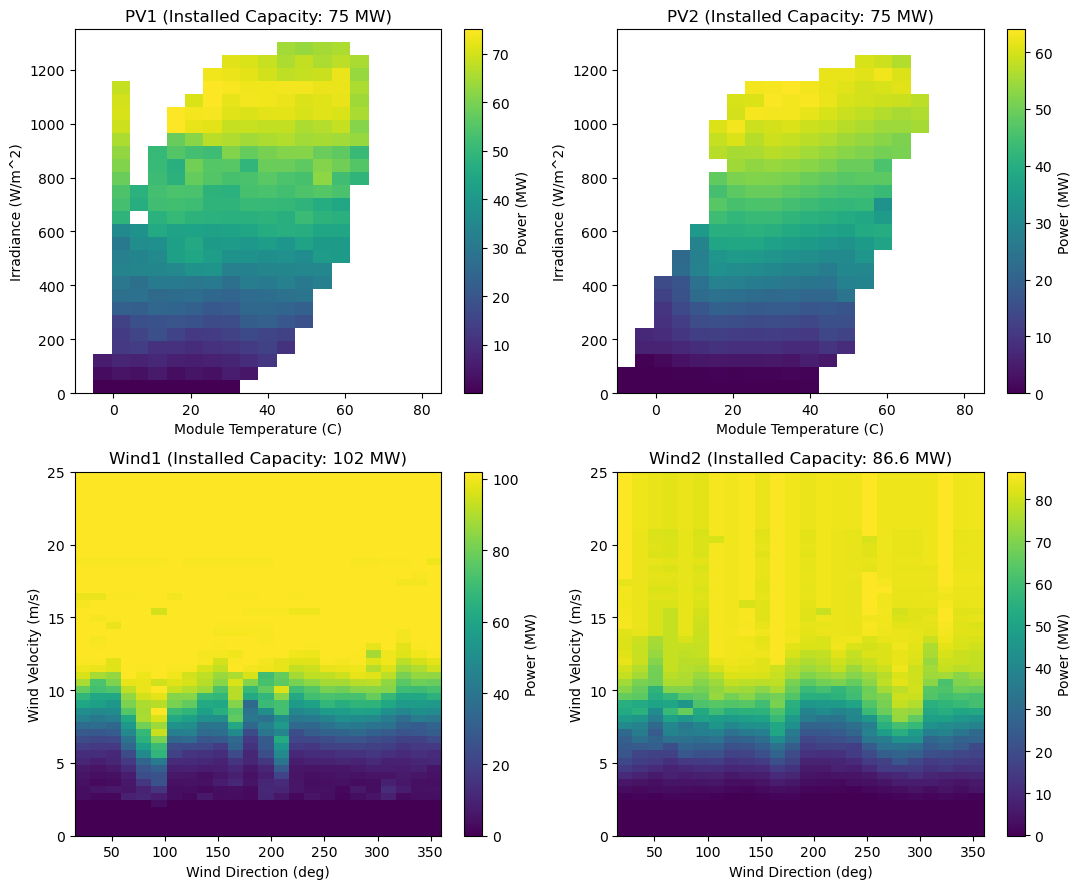

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, sheet_name in zip(axes.flat, ["PV1", "PV2", "Wind1", "Wind2"]):
    g = grids[sheet_name]
    is_pv = sheet_name.startswith("PV")
    im = ax.imshow(
        g["power_grid"], origin="lower", aspect="auto",
        extent=[g["x_axis"].min(), g["x_axis"].max(), g["y_axis"].min(), g["y_axis"].max()],
    )
    ax.set_title(f"{sheet_name} ({g['capacity_label']})")
    ax.set_xlabel("Module Temperature (C)" if is_pv else "Wind Direction (deg)")
    ax.set_ylabel("Irradiance (W/m^2)" if is_pv else "Wind Velocity (m/s)")
    fig.colorbar(im, ax=ax, label="Power (MW)")
fig.tight_layout()
fig.savefig("outputs/all_sheets_raw_grids.png", dpi=150)
plt.show()

### PV missingness pattern

Fill rate for PV1 and PV2, checked against the documented values.

In [7]:
for sheet_name in ["PV1", "PV2"]:
    power_grid = grids[sheet_name]["power_grid"]
    fill_rate = 100 * (1 - np.isnan(power_grid).mean())
    print(f"{sheet_name}: {fill_rate:.1f}% filled ({np.isnan(power_grid).sum()} missing cells)")

PV1: 53.2% filled (262 missing cells)
PV2: 47.9% filled (292 missing cells)


### PV missingness heatmap

Where the missing cells fall in (irradiance, module temperature) space, for PV1 and PV2 side by side.

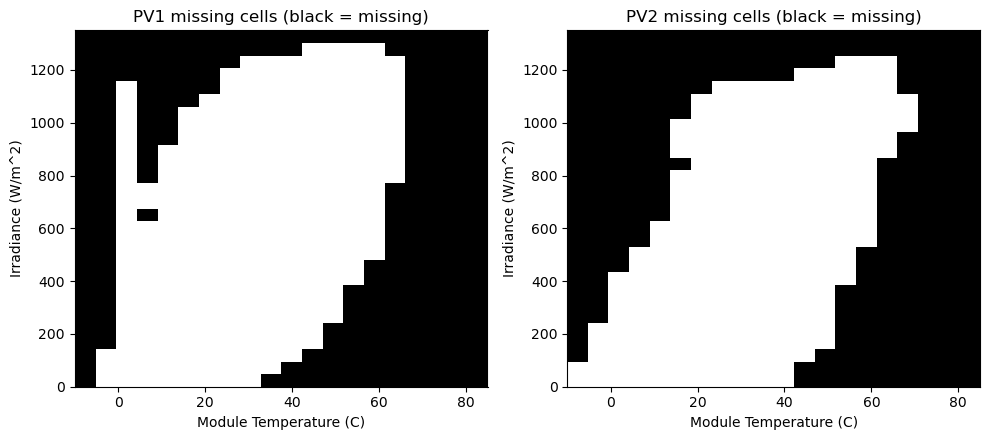

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, sheet_name in zip(axes, ["PV1", "PV2"]):
    g = grids[sheet_name]
    missing_mask = np.isnan(g["power_grid"])
    ax.imshow(
        missing_mask, origin="lower", aspect="auto", cmap="gray_r",
        extent=[g["x_axis"].min(), g["x_axis"].max(), g["y_axis"].min(), g["y_axis"].max()],
    )
    ax.set_title(f"{sheet_name} missing cells (black = missing)")
    ax.set_xlabel("Module Temperature (C)")
    ax.set_ylabel("Irradiance (W/m^2)")
fig.tight_layout()
fig.savefig("outputs/pv1_pv2_missingness.png", dpi=150)
plt.show()

### Wind2 negative-value check

Locate the documented near-zero negative artifact before deciding how to handle it.

In [9]:
wind2_grid = grids["Wind2"]["power_grid"]
wind2_velocity = grids["Wind2"]["y_axis"]
wind2_direction = grids["Wind2"]["x_axis"]

for row, col in np.argwhere(wind2_grid < 0):
    print(
        f"velocity={wind2_velocity[row]} m/s, direction={wind2_direction[col]} deg, "
        f"power={wind2_grid[row, col]:.4f} MW"
    )

velocity=2.5 m/s, direction=240.0 deg, power=-0.0948 MW
velocity=2.5 m/s, direction=255.0 deg, power=-0.0573 MW


### Clip Wind2 artifact

Clip the negative cell(s) to 0 in place; this is measurement noise around zero wind speed, not real negative generation.

In [10]:
# Clip near-zero negative artifact (measurement noise around zero wind speed, not real
# negative generation) -- see the Wind2 negative-value check above for the flagged cell(s).
grids["Wind2"]["power_grid"] = np.clip(wind2_grid, 0.0, None)
print("remaining negative cells:", (grids["Wind2"]["power_grid"] < 0).sum())

remaining negative cells: 0


### Discussion

The raw grids look physically sane: PV1/PV2 power rises with irradiance and eases off with
higher module temperature at fixed irradiance, and both wind plants show the expected S-curve,
cutting in near 3 m/s and flattening at rated capacity (102 MW / 86.6 MW) by around 10-12 m/s,
with no strong dependence on wind direction.

PV1 is 53.2% filled (262 of 560 cells missing), PV2 is 47.9% filled (292 of 560), matching the
documented fill rates. The missingness heatmap shows why: filled cells form a diagonal band
running from (low irradiance, low temperature) to (high irradiance, high temperature). The
missing corners, cold module with high irradiance and hot module with little irradiance, are
combinations that essentially never occur in the field because irradiance is what heats the
module. This is a sampling artifact of physically coupled inputs, not a data quality problem, so
it is left as unsampled space for the models to generalize into rather than something to impute.

The Wind2 check found two near-zero negative cells (-0.095 MW and -0.057 MW), both at 2.5 m/s
(below cut-in), at wind directions 240 and 255 degrees, not the single cell the source
description mentioned. Both are measurement noise around zero, not real negative generation, and
have been clipped to 0 in `grids["Wind2"]["power_grid"]`.

## PV1 Model

Physics formula and ML models for PV1, compared directly, especially in the unsampled region.

### Tidy long format

Reshape the PV1 grid to one row per (irradiance, module temperature) cell, dropping true NaNs.

In [11]:
irradiance_mesh, temp_mesh = np.meshgrid(grids["PV1"]["y_axis"], grids["PV1"]["x_axis"], indexing="ij")
pv1_df = pd.DataFrame({
    "irradiance": irradiance_mesh.ravel(),
    "module_temp": temp_mesh.ravel(),
    "power": grids["PV1"]["power_grid"].ravel(),
})
pv1_df = pv1_df.dropna(subset=["power"]).reset_index(drop=True)

In [12]:
n_rows, n_cols = grids["PV1"]["power_grid"].shape
print(f"PV1: retained {len(pv1_df)} of {n_rows * n_cols} grid cells ({n_rows} irradiance x {n_cols} temperature)")

PV1: retained 298 of 560 grid cells (28 irradiance x 20 temperature)


### Physics formula

Standard linear temperature-coefficient PV model [1]:

P = beta0 * G + beta1 * G * (Tm - 25)

where G is irradiance (W/m^2) and Tm is module temperature (C), fit by ordinary least squares
on `[G, G*(Tm-25)]` with no intercept.

In [13]:
from sklearn.linear_model import LinearRegression

X_pv1 = np.column_stack([pv1_df["irradiance"], pv1_df["irradiance"] * (pv1_df["module_temp"] - 25)])
y_pv1 = pv1_df["power"].to_numpy()

pv1_physics_model = LinearRegression(fit_intercept=False).fit(X_pv1, y_pv1)
beta0_pv1, beta1_pv1 = pv1_physics_model.coef_

In [14]:
print(f"PV1 physics formula: beta0 = {beta0_pv1:.5f} MW per W/m^2, beta1 = {beta1_pv1:.6f} MW per W/m^2 per degC")

PV1 physics formula: beta0 = 0.06708 MW per W/m^2, beta1 = -0.000124 MW per W/m^2 per degC


### Cross-validation helper

Reusable 5-fold CV evaluator (R^2, RMSE), used by every model in the notebook.

In [15]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

def cv_evaluate(model_fn, X, y, n_splits=CV_FOLDS, random_state=0):
    """5-fold CV R^2/RMSE for a model_fn() -> unfitted estimator, over grid-cell rows."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    r2_scores, rmse_scores = [], []
    for train_idx, test_idx in kf.split(X):
        model = model_fn().fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        r2_scores.append(r2_score(y[test_idx], pred))
        rmse_scores.append(np.sqrt(mean_squared_error(y[test_idx], pred)))
    return np.array(r2_scores), np.array(rmse_scores)

### Physics formula cross-validation

5-fold CV R^2/RMSE for the PV1 physics formula.

In [16]:
r2_pv1_physics, rmse_pv1_physics = cv_evaluate(lambda: LinearRegression(fit_intercept=False), X_pv1, y_pv1)
print(f"PV1 physics formula 5-fold CV: R^2 = {r2_pv1_physics.mean():.4f} +/- {r2_pv1_physics.std():.4f}, "
      f"RMSE = {rmse_pv1_physics.mean():.4f} +/- {rmse_pv1_physics.std():.4f} MW")

PV1 physics formula 5-fold CV: R^2 = 0.9383 +/- 0.0202, RMSE = 5.2506 +/- 0.5614 MW


### Gaussian Process Regression

Primary ML comparison model: well suited to small, smooth 2D data, with predictive uncertainty as a bonus.

In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def make_gp():
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF([1.0, 1.0], (1e-2, 1e2)) + WhiteKernel(1.0, (1e-5, 1e2))
    return make_pipeline(
        StandardScaler(),
        GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=3, random_state=0),
    )

# GP/RF map raw (irradiance, module_temp) to power, not the physics-transformed [G, G*(Tm-25)]
# features used for the OLS fit above -- a separate X_pv1_ml keeps this consistent with the raw
# grid used for full-grid prediction later.
X_pv1_ml = np.column_stack([pv1_df["irradiance"], pv1_df["module_temp"]])

pv1_gp_model = make_gp().fit(X_pv1_ml, y_pv1)
print("PV1 GP fitted kernel:", pv1_gp_model.named_steps["gaussianprocessregressor"].kernel_)

PV1 GP fitted kernel: 0.807**2 * RBF(length_scale=[0.488, 1.89]) + WhiteKernel(noise_level=0.011)


### GP cross-validation

5-fold CV R^2/RMSE for the PV1 GP model.

In [18]:
r2_pv1_gp, rmse_pv1_gp = cv_evaluate(make_gp, X_pv1_ml, y_pv1)
print(f"PV1 GP 5-fold CV: R^2 = {r2_pv1_gp.mean():.4f} +/- {r2_pv1_gp.std():.4f}, "
      f"RMSE = {rmse_pv1_gp.mean():.4f} +/- {rmse_pv1_gp.std():.4f} MW")

PV1 GP 5-fold CV: R^2 = 0.9860 +/- 0.0030, RMSE = 2.5368 +/- 0.2928 MW


### Random Forest

Secondary ML contrast: tree ensembles are expected to extrapolate poorly outside their training support.

In [19]:
from sklearn.ensemble import RandomForestRegressor

def make_rf():
    return RandomForestRegressor(n_estimators=300, random_state=0)

pv1_rf_model = make_rf().fit(X_pv1_ml, y_pv1)
importances = pv1_rf_model.feature_importances_
print(f"PV1 RF feature importances: irradiance = {importances[0]:.3f}, module_temp = {importances[1]:.3f}")

PV1 RF feature importances: irradiance = 0.988, module_temp = 0.012


### Random Forest cross-validation

5-fold CV R^2/RMSE for the PV1 Random Forest model.

In [20]:
r2_pv1_rf, rmse_pv1_rf = cv_evaluate(make_rf, X_pv1_ml, y_pv1)
print(f"PV1 RF 5-fold CV: R^2 = {r2_pv1_rf.mean():.4f} +/- {r2_pv1_rf.std():.4f}, "
      f"RMSE = {rmse_pv1_rf.mean():.4f} +/- {rmse_pv1_rf.std():.4f} MW")

PV1 RF 5-fold CV: R^2 = 0.9890 +/- 0.0021, RMSE = 2.2466 +/- 0.2342 MW


### Full-grid predictions

Predict all three PV1 models over the complete native grid, including the unsampled cells.

In [21]:
full_irr_mesh, full_temp_mesh = np.meshgrid(grids["PV1"]["y_axis"], grids["PV1"]["x_axis"], indexing="ij")
X_pv1_full = np.column_stack([full_irr_mesh.ravel(), full_temp_mesh.ravel()])
X_pv1_full_physics = np.column_stack([X_pv1_full[:, 0], X_pv1_full[:, 0] * (X_pv1_full[:, 1] - 25)])

pv1_pred_physics = pv1_physics_model.predict(X_pv1_full_physics).reshape(full_irr_mesh.shape)
pv1_pred_gp = pv1_gp_model.predict(X_pv1_full).reshape(full_irr_mesh.shape)
pv1_pred_rf = pv1_rf_model.predict(X_pv1_full).reshape(full_irr_mesh.shape)

### Response-surface heatmaps

Actual grid next to each model's full-grid prediction, same color scale, the central PV1 figure.

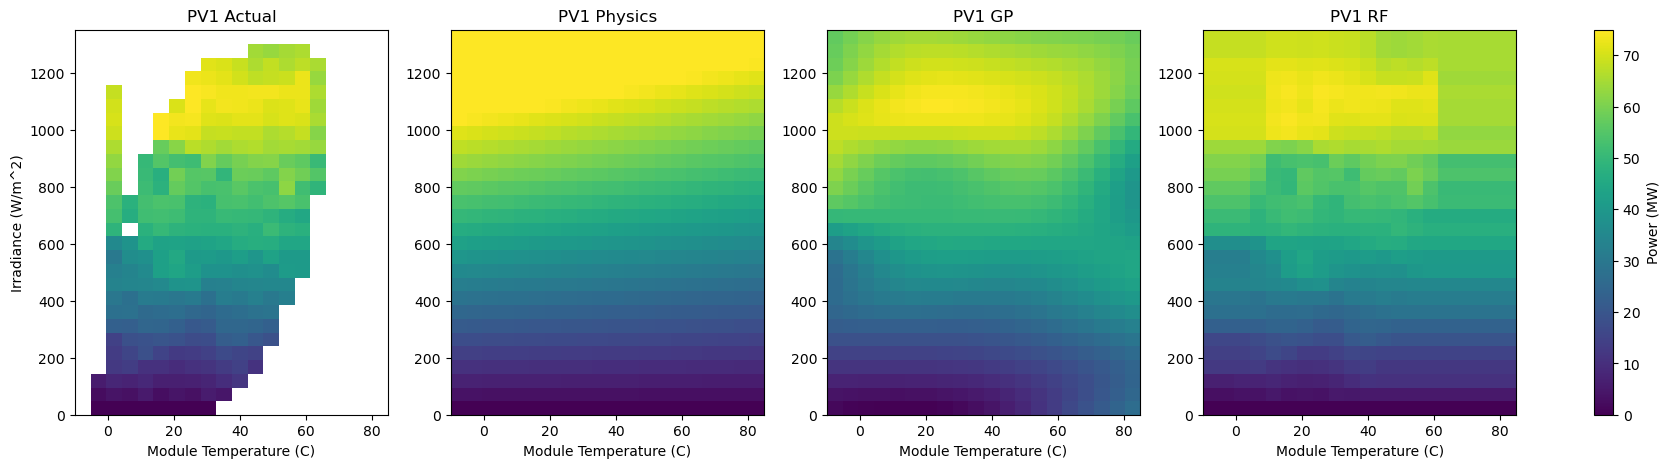

In [22]:
pv1_extent = [grids["PV1"]["x_axis"].min(), grids["PV1"]["x_axis"].max(),
              grids["PV1"]["y_axis"].min(), grids["PV1"]["y_axis"].max()]
pv1_panels = [
    ("Actual", grids["PV1"]["power_grid"]),
    ("Physics", pv1_pred_physics),
    ("GP", pv1_pred_gp),
    ("RF", pv1_pred_rf),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, grid_) in zip(axes, pv1_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=pv1_extent, vmin=0, vmax=CAPACITY_MW["PV1"])
    ax.set_title(f"PV1 {title}")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/pv1_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual, only where actual data exists (blank in the unsampled region, since there is no ground truth there).

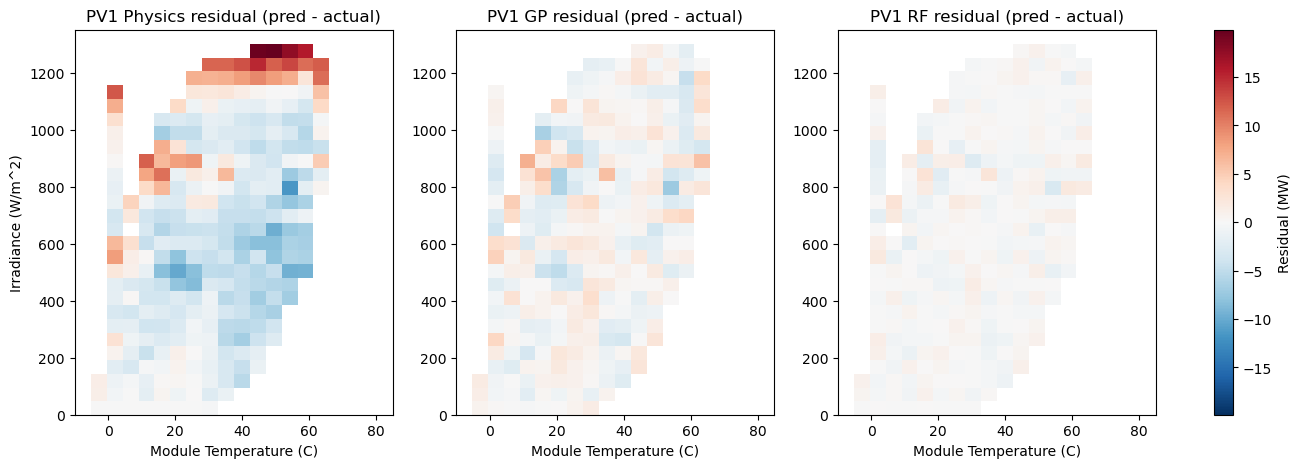

In [23]:
pv1_actual = grids["PV1"]["power_grid"]
pv1_resid_panels = [
    ("Physics", pv1_pred_physics - pv1_actual),
    ("GP", pv1_pred_gp - pv1_actual),
    ("RF", pv1_pred_rf - pv1_actual),
]
max_abs_resid = np.nanmax(np.abs(np.stack([r for _, r in pv1_resid_panels])))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, resid) in zip(axes, pv1_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=pv1_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid, vmax=max_abs_resid)
    ax.set_title(f"PV1 {title} residual (pred - actual)")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/pv1_residuals.png", dpi=150)
plt.show()

### Discussion

All three models learn the same dominant shape: power rises steeply with irradiance and eases
only modestly with module temperature (RF puts 98.8% of its feature importance on irradiance).
The physics formula extrapolates as a smooth linear gradient with no local texture, while GP and
RF both track the actual grid's diagonal footprint more closely inside the sampled region before
smoothing out into the unsampled corners.

The residual heatmaps show the physics formula has the largest, most structured errors, up to
19.9 MW at the (1300 W/m^2, 50 C) cell, matching its higher CV RMSE (5.25 MW vs. 2.54 MW for GP
and 2.25 MW for RF). GP and RF residuals are much smaller (7.3 MW and 3.1 MW max respectively)
and mostly scattered, though both happen to peak at the same (800 W/m^2, 55 C) cell.

The more important difference is in the unsampled region itself: the physics formula is a pure
linear fit with no saturation term, so it keeps climbing past the plant's 75 MW nameplate capacity.
It predicts above 75 MW for 26 of 298 sampled cells (8.7%) and 65 of 262 unsampled cells (24.8%),
peaking at 96.4 MW at the highest-irradiance corner. GP and RF cannot do this: both stay at or
just under the observed maximum by construction (74.8 MW and 74.7 MW respectively), so their
extrapolated predictions stay physically plausible even though they were not designed to enforce
a capacity cap. For extrapolated dispatch estimates in the unsampled region, the physics formula
in its current linear form is the riskier choice; a capacity-aware clip or a saturating formula
would fix this specific failure mode.

### SHAP summary

Global feature importance for the ML models only; the physics formula's two fitted coefficients are already the explanation.

In [24]:
import shap

pv1_rf_explainer = shap.TreeExplainer(pv1_rf_model)
pv1_rf_shap_values = pv1_rf_explainer.shap_values(X_pv1_ml)
print("PV1 RF SHAP values shape:", pv1_rf_shap_values.shape)

PV1 RF SHAP values shape: (298, 2)


In [25]:
pv1_gp_background = shap.sample(X_pv1_ml, 50, random_state=0)
pv1_gp_explainer = shap.Explainer(pv1_gp_model.predict, pv1_gp_background)
pv1_gp_shap_values = pv1_gp_explainer(X_pv1_ml)
print("PV1 GP SHAP values shape:", pv1_gp_shap_values.values.shape)

PV1 GP SHAP values shape: (298, 2)


PV1 RF mean |SHAP|: {'irradiance': np.float64(18.237), 'module_temp': np.float64(0.88)}
PV1 GP mean |SHAP|: {'irradiance': np.float64(17.885), 'module_temp': np.float64(0.771)}


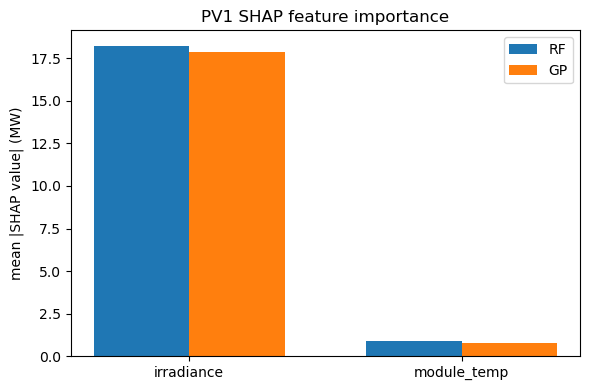

In [26]:
pv1_feature_names = ["irradiance", "module_temp"]
pv1_rf_mean_abs_shap = np.abs(pv1_rf_shap_values).mean(axis=0)
pv1_gp_mean_abs_shap = np.abs(pv1_gp_shap_values.values).mean(axis=0)
print("PV1 RF mean |SHAP|:", dict(zip(pv1_feature_names, pv1_rf_mean_abs_shap.round(3))))
print("PV1 GP mean |SHAP|:", dict(zip(pv1_feature_names, pv1_gp_mean_abs_shap.round(3))))

x = np.arange(len(pv1_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, pv1_rf_mean_abs_shap, width, label="RF")
ax.bar(x + width / 2, pv1_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(pv1_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("PV1 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/pv1_shap_summary.png", dpi=150)
plt.show()

### Discussion

SHAP agrees with the RF feature importances above: irradiance dominates both models (RF mean
|SHAP| = 18.2 MW vs. 0.9 MW for module_temp; GP mean |SHAP| = 17.9 MW vs. 0.8 MW). RF and GP
weight module_temp almost identically lightly (0.9 vs. 0.8 MW), consistent with both models'
near-horizontal response-surface panels above and the tiny fitted beta1 in the physics formula:
module temperature is a real but minor secondary driver of PV1 power, irradiance is overwhelmingly
the dominant one.

### Standalone script export

Exports `models/pv1_model.py`, which refits all three PV1 models on import and exposes `predict(irradiance, module_temp, model=...)`.

In [27]:
from models.pv1_model import predict as pv1_predict

for model_name in ["physics", "gp", "rf"]:
    print(f"models/pv1_model.py predict(800, 40, model='{model_name}') = {pv1_predict(800, 40, model=model_name):.2f} MW")

models/pv1_model.py predict(800, 40, model='physics') = 52.18 MW
models/pv1_model.py predict(800, 40, model='gp') = 54.47 MW
models/pv1_model.py predict(800, 40, model='rf') = 55.17 MW


## PV2 Model

Physics formula and ML models for PV2, mirroring the PV1 model block.

### Tidy long format

Reshape the PV2 grid to one row per (irradiance, module temperature) cell, dropping true NaNs.

In [28]:
irr_mesh_pv2, temp_mesh_pv2 = np.meshgrid(grids["PV2"]["y_axis"], grids["PV2"]["x_axis"], indexing="ij")
pv2_df = pd.DataFrame({
    "irradiance": irr_mesh_pv2.ravel(),
    "module_temp": temp_mesh_pv2.ravel(),
    "power": grids["PV2"]["power_grid"].ravel(),
})
pv2_df = pv2_df.dropna(subset=["power"]).reset_index(drop=True)

In [29]:
n_rows_pv2, n_cols_pv2 = grids["PV2"]["power_grid"].shape
print(f"PV2: retained {len(pv2_df)} of {n_rows_pv2 * n_cols_pv2} grid cells ({n_rows_pv2} irradiance x {n_cols_pv2} temperature)")

PV2: retained 268 of 560 grid cells (28 irradiance x 20 temperature)


### Physics formula

Same linear temperature-coefficient model [1] used for PV1, refit here on PV2's own tidy data
rather than reusing PV1's coefficients, since the two plants are physically separate arrays and
are expected to have different fitted parameters:

P = beta0 * G + beta1 * G * (Tm - 25)

Fit by ordinary least squares on `[G, G*(Tm-25)]` with no intercept, same as PV1.

In [30]:
X_pv2 = np.column_stack([pv2_df["irradiance"], pv2_df["irradiance"] * (pv2_df["module_temp"] - 25)])
y_pv2 = pv2_df["power"].to_numpy()

pv2_physics_model = LinearRegression(fit_intercept=False).fit(X_pv2, y_pv2)
beta0_pv2, beta1_pv2 = pv2_physics_model.coef_
print(f"PV2 physics formula: beta0 = {beta0_pv2:.5f} MW per W/m^2, beta1 = {beta1_pv2:.6f} MW per W/m^2 per degC")

PV2 physics formula: beta0 = 0.06077 MW per W/m^2, beta1 = -0.000160 MW per W/m^2 per degC


### Physics formula cross-validation

5-fold CV R^2/RMSE for the PV2 physics formula, using the same `cv_evaluate` helper defined in
the PV1 block, so the metrics are directly comparable across the two plants.

In [31]:
r2_pv2_physics, rmse_pv2_physics = cv_evaluate(lambda: LinearRegression(fit_intercept=False), X_pv2, y_pv2)
print(f"PV2 physics formula 5-fold CV: R^2 = {r2_pv2_physics.mean():.4f} +/- {r2_pv2_physics.std():.4f}, "
      f"RMSE = {rmse_pv2_physics.mean():.4f} +/- {rmse_pv2_physics.std():.4f} MW")

PV2 physics formula 5-fold CV: R^2 = 0.9722 +/- 0.0047, RMSE = 3.4112 +/- 0.3539 MW


### Gaussian Process Regression

Primary ML comparison model for PV2, same `make_gp()` factory (scaled RBF + white-noise kernel)
defined in the PV1 block, refit here on PV2's tidy data.

In [32]:
# Same raw-feature fix as PV1: GP/RF map (irradiance, module_temp) directly, not the
# physics-transformed [G, G*(Tm-25)] features used for the OLS fit above.
X_pv2_ml = np.column_stack([pv2_df["irradiance"], pv2_df["module_temp"]])

pv2_gp_model = make_gp().fit(X_pv2_ml, y_pv2)
print("PV2 GP fitted kernel:", pv2_gp_model.named_steps["gaussianprocessregressor"].kernel_)

PV2 GP fitted kernel: 0.833**2 * RBF(length_scale=[0.726, 1.45]) + WhiteKernel(noise_level=0.00301)


### GP cross-validation

5-fold CV R^2/RMSE for the PV2 GP model, using the same `cv_evaluate` helper and fold count as
every other model in the notebook.

In [33]:
r2_pv2_gp, rmse_pv2_gp = cv_evaluate(make_gp, X_pv2_ml, y_pv2)
print(f"PV2 GP 5-fold CV: R^2 = {r2_pv2_gp.mean():.4f} +/- {r2_pv2_gp.std():.4f}, "
      f"RMSE = {rmse_pv2_gp.mean():.4f} +/- {rmse_pv2_gp.std():.4f} MW")

PV2 GP 5-fold CV: R^2 = 0.9961 +/- 0.0012, RMSE = 1.2715 +/- 0.1686 MW


### Random Forest

Secondary ML contrast for PV2, same `make_rf()` factory defined in the PV1 block, refit here on
PV2's tidy data to see whether the irradiance-dominant feature importance pattern from PV1 holds.

In [34]:
pv2_rf_model = make_rf().fit(X_pv2_ml, y_pv2)
importances_pv2 = pv2_rf_model.feature_importances_
print(f"PV2 RF feature importances: irradiance = {importances_pv2[0]:.3f}, module_temp = {importances_pv2[1]:.3f}")

PV2 RF feature importances: irradiance = 0.988, module_temp = 0.012


### Random Forest cross-validation

5-fold CV R^2/RMSE for the PV2 Random Forest model, directly comparable to the physics formula
and GP numbers above.

In [35]:
r2_pv2_rf, rmse_pv2_rf = cv_evaluate(make_rf, X_pv2_ml, y_pv2)
print(f"PV2 RF 5-fold CV: R^2 = {r2_pv2_rf.mean():.4f} +/- {r2_pv2_rf.std():.4f}, "
      f"RMSE = {rmse_pv2_rf.mean():.4f} +/- {rmse_pv2_rf.std():.4f} MW")

PV2 RF 5-fold CV: R^2 = 0.9935 +/- 0.0017, RMSE = 1.6397 +/- 0.1774 MW


### Full-grid predictions

Predict all three PV2 models (physics, GP, RF) over the complete native grid, including the
unsampled cells, the same way as PV1, so the two plants' extrapolation behavior can be compared
side by side.

In [36]:
full_irr_mesh_pv2, full_temp_mesh_pv2 = np.meshgrid(grids["PV2"]["y_axis"], grids["PV2"]["x_axis"], indexing="ij")
X_pv2_full = np.column_stack([full_irr_mesh_pv2.ravel(), full_temp_mesh_pv2.ravel()])
X_pv2_full_physics = np.column_stack([X_pv2_full[:, 0], X_pv2_full[:, 0] * (X_pv2_full[:, 1] - 25)])

pv2_pred_physics = pv2_physics_model.predict(X_pv2_full_physics).reshape(full_irr_mesh_pv2.shape)
pv2_pred_gp = pv2_gp_model.predict(X_pv2_full).reshape(full_irr_mesh_pv2.shape)
pv2_pred_rf = pv2_rf_model.predict(X_pv2_full).reshape(full_irr_mesh_pv2.shape)
print("PV2 full-grid predictions shape:", pv2_pred_physics.shape)

PV2 full-grid predictions shape: (28, 20)


### Response-surface heatmaps

Actual PV2 grid next to each model's full-grid prediction, same color scale and layout as the
PV1 figure, the central PV2 figure.

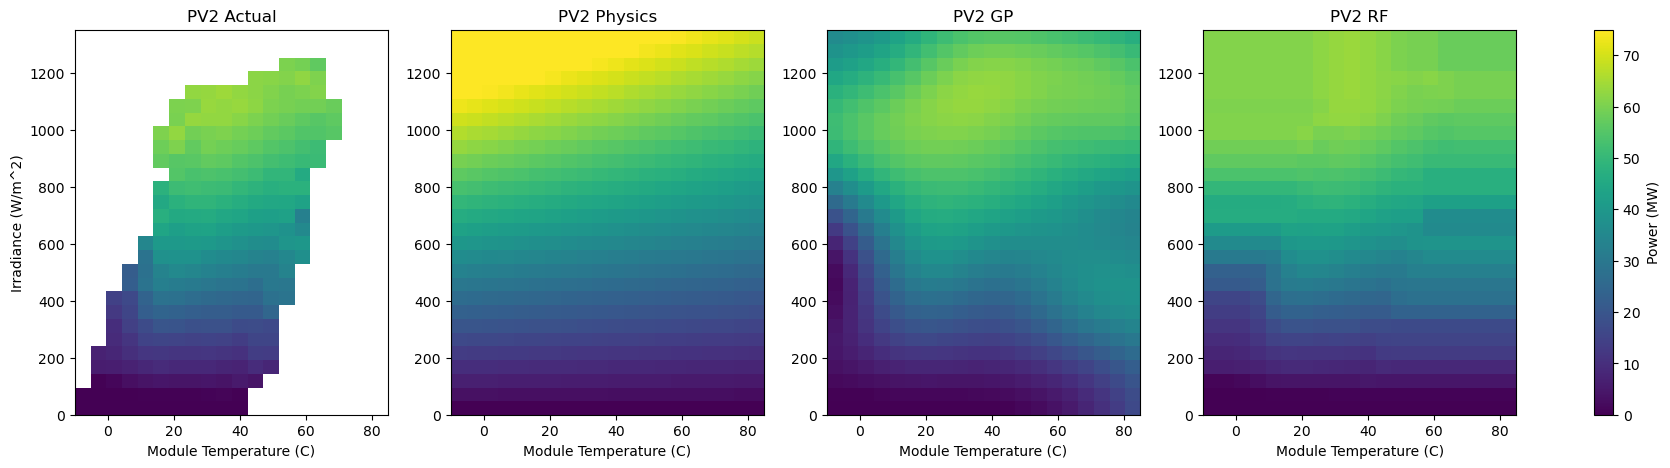

In [37]:
pv2_extent = [grids["PV2"]["x_axis"].min(), grids["PV2"]["x_axis"].max(),
              grids["PV2"]["y_axis"].min(), grids["PV2"]["y_axis"].max()]
pv2_panels = [
    ("Actual", grids["PV2"]["power_grid"]),
    ("Physics", pv2_pred_physics),
    ("GP", pv2_pred_gp),
    ("RF", pv2_pred_rf),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, grid_) in zip(axes, pv2_panels):
    im = ax.imshow(grid_, origin="lower", aspect="auto", extent=pv2_extent, vmin=0, vmax=CAPACITY_MW["PV2"])
    ax.set_title(f"PV2 {title}")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Power (MW)", fraction=0.02)
fig.savefig("outputs/pv2_response_surface.png", dpi=150)
plt.show()

### Residual heatmaps

Prediction minus actual for PV2, only where actual data exists (blank in the unsampled region,
since there is no ground truth there), same layout as the PV1 residual figure.

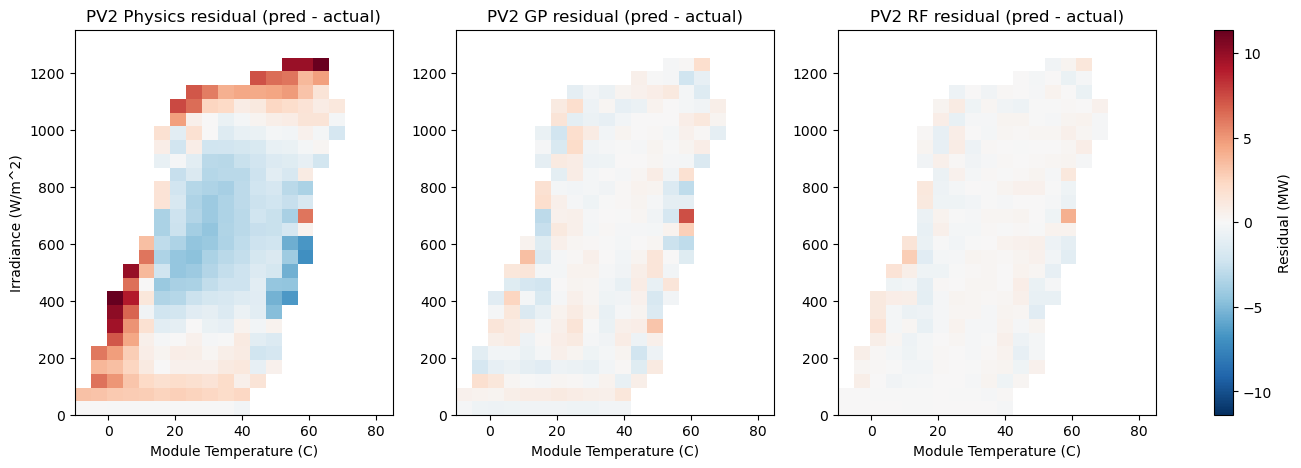

In [38]:
pv2_actual = grids["PV2"]["power_grid"]
pv2_resid_panels = [
    ("Physics", pv2_pred_physics - pv2_actual),
    ("GP", pv2_pred_gp - pv2_actual),
    ("RF", pv2_pred_rf - pv2_actual),
]
max_abs_resid_pv2 = np.nanmax(np.abs(np.stack([r for _, r in pv2_resid_panels])))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, resid) in zip(axes, pv2_resid_panels):
    im = ax.imshow(resid, origin="lower", aspect="auto", extent=pv2_extent,
                    cmap="RdBu_r", vmin=-max_abs_resid_pv2, vmax=max_abs_resid_pv2)
    ax.set_title(f"PV2 {title} residual (pred - actual)")
    ax.set_xlabel("Module Temperature (C)")
axes[0].set_ylabel("Irradiance (W/m^2)")
fig.colorbar(im, ax=axes, label="Residual (MW)", fraction=0.02)
fig.savefig("outputs/pv2_residuals.png", dpi=150)
plt.show()

### Discussion

PV2 shows the same overall pattern as PV1, but with tighter fits across all three models:
physics R^2 = 0.9722 (RMSE = 3.41 MW), GP R^2 = 0.9961 (RMSE = 1.27 MW), RF R^2 = 0.9935
(RMSE = 1.64 MW), all beating their PV1 counterparts (5.25 / 2.54 / 2.25 MW respectively). The
residual heatmaps put the physics formula's error where PV1's did: structured, up to 11.4 MW at
the (400 W/m^2, 0 C) cell, while GP and RF residuals are smaller (7.4 MW and 4.1 MW max) and
mostly scattered, aside from a shared outlier cell at (700 W/m^2, 60 C) that both ML models miss
in the same spot.

The extrapolation risk shows up again but milder: the linear physics formula, with no saturation
term, predicts above PV2's 75 MW nameplate capacity in 40 of 292 unsampled cells (13.7%, versus
PV1's 24.8%) while staying within cap on every sampled cell, peaking at 89.6 MW in the
highest-irradiance corner. GP and RF again stay bounded by construction, topping out near
63 MW across the full grid. The conclusion from PV1 carries over: for extrapolated dispatch
estimates in the unsampled region, the physics formula's raw linear form is the riskier choice
for PV2 as well.

### SHAP summary

Global feature importance for the PV2 GP and RF models, same approach as PV1 (TreeExplainer for
RF, a sampled-background KernelExplainer-style `Explainer` for GP); the physics formula needs no
SHAP since its two fitted coefficients are already the explanation.

In [39]:
pv2_rf_explainer = shap.TreeExplainer(pv2_rf_model)
pv2_rf_shap_values = pv2_rf_explainer.shap_values(X_pv2_ml)
print("PV2 RF SHAP values shape:", pv2_rf_shap_values.shape)

PV2 RF SHAP values shape: (268, 2)


In [40]:
pv2_gp_background = shap.sample(X_pv2_ml, 50, random_state=0)
pv2_gp_explainer = shap.Explainer(pv2_gp_model.predict, pv2_gp_background)
pv2_gp_shap_values = pv2_gp_explainer(X_pv2_ml)
print("PV2 GP SHAP values shape:", pv2_gp_shap_values.values.shape)

PV2 GP SHAP values shape: (268, 2)


PV2 RF mean |SHAP|: {'irradiance': np.float64(18.135), 'module_temp': np.float64(1.251)}
PV2 GP mean |SHAP|: {'irradiance': np.float64(17.345), 'module_temp': np.float64(1.458)}


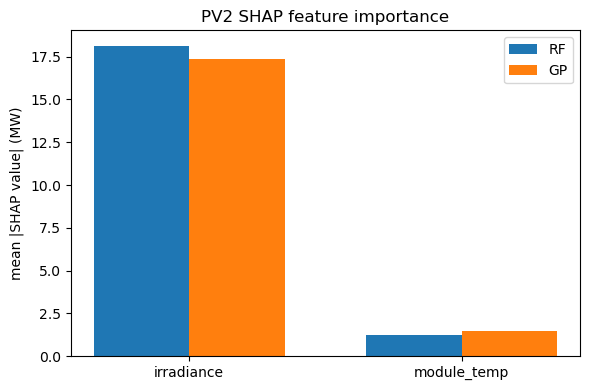

In [41]:
pv2_feature_names = ["irradiance", "module_temp"]
pv2_rf_mean_abs_shap = np.abs(pv2_rf_shap_values).mean(axis=0)
pv2_gp_mean_abs_shap = np.abs(pv2_gp_shap_values.values).mean(axis=0)
print("PV2 RF mean |SHAP|:", dict(zip(pv2_feature_names, pv2_rf_mean_abs_shap.round(3))))
print("PV2 GP mean |SHAP|:", dict(zip(pv2_feature_names, pv2_gp_mean_abs_shap.round(3))))

x = np.arange(len(pv2_feature_names))
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width / 2, pv2_rf_mean_abs_shap, width, label="RF")
ax.bar(x + width / 2, pv2_gp_mean_abs_shap, width, label="GP")
ax.set_xticks(x)
ax.set_xticklabels(pv2_feature_names)
ax.set_ylabel("mean |SHAP value| (MW)")
ax.set_title("PV2 SHAP feature importance")
ax.legend()
fig.tight_layout()
fig.savefig("outputs/pv2_shap_summary.png", dpi=150)
plt.show()

### Discussion

Same story as PV1: irradiance dominates both PV2 models (RF mean |SHAP| = 18.1 MW vs. 1.3 MW for
module_temp; GP mean |SHAP| = 17.3 MW vs. 1.5 MW). Module_temp carries a bit more weight here than
in PV1 for both models (1.3-1.5 MW vs. PV1's 0.8-0.9 MW), matching PV2's larger-magnitude fitted
beta1 (-0.000160 vs. PV1's -0.000124), but irradiance still overwhelmingly dominates in both
plants.

### Standalone script export

Exports `models/pv2_model.py`, which refits all three PV2 models on import and exposes
`predict(irradiance, module_temp, model=...)`, mirroring `models/pv1_model.py`.

In [42]:
from models.pv2_model import predict as pv2_predict

for model_name in ["physics", "gp", "rf"]:
    print(f"models/pv2_model.py predict(800, 40, model='{model_name}') = {pv2_predict(800, 40, model=model_name):.2f} MW")

models/pv2_model.py predict(800, 40, model='physics') = 46.70 MW
models/pv2_model.py predict(800, 40, model='gp') = 49.79 MW
models/pv2_model.py predict(800, 40, model='rf') = 49.99 MW


## PV-combined Model

Physics formula and ML models fit on PV1 and PV2 pooled together, with plant as an added
categorical feature, to check whether pooling helps or hurts versus the two standalone models.

### Tidy long format

Pool PV1's and PV2's already-tidy DataFrames, each tagged with a `plant` column, into one combined
table; both were already dropped of true NaNs when they were built, so no further filtering is
needed here.

In [43]:
pv_combined_df = pd.concat(
    [pv1_df.assign(plant="PV1"), pv2_df.assign(plant="PV2")],
    ignore_index=True,
)
print(f"PV-combined: {len(pv_combined_df)} rows ({(pv_combined_df['plant'] == 'PV1').sum()} PV1 + "
      f"{(pv_combined_df['plant'] == 'PV2').sum()} PV2)")

PV-combined: 566 rows (298 PV1 + 268 PV2)
